# Stance Classification: VADER · BoW Logistic Regression · BERT
Trains three models on `mock_comments_100.json` and applies them to live data from MongoDB.

**Labels:** `positive` / `negative` based on commenter stance toward a proposal.

## 0 · Install dependencies
Run once. Restart the kernel after the cell completes.

In [1]:
%pip install -q vaderSentiment scikit-learn transformers torch pymongo tiktoken matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1 · Load mock training data

In [2]:
import json
import pandas as pd

with open("mock_comments_100.json") as f:
    mock_data = json.load(f)

df = pd.DataFrame([
    {"text": d["raw_text"], "label": d["stance"]}
    for d in mock_data
])

# Binary encode: positive=1, negative=0
df["label_int"] = (df["label"] == "positive").astype(int)

print(f"Dataset: {len(df)} rows")
print(df["label"].value_counts())
df.head()

Dataset: 100 rows
label
negative    50
positive    50
Name: count, dtype: int64


,text,label,label_int
0,This doesn't handle the edge case where a pack...,negative,0
1,I tested this locally and it works perfectly. ...,positive,1
2,I think we're solving the wrong problem. The w...,negative,0
3,The performance overhead is negligible accordi...,positive,1
4,This forces an unnecessary dependency on ctype...,negative,0


## 2 · Train / test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label_int"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_int"]
)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 80  |  Test: 20


---
## Algorithm 1 · VADER (rule-based, no training required)
VADER uses a pre-built sentiment lexicon — no fitting step. The compound score
is thresholded at 0 to map to positive / negative stance.

  VADER — Evaluation on held-out test set
  Accuracy  : 0.8000
  Precision : 0.8571  (macro avg)
  Recall    : 0.8000  (macro avg)
  F1        : 0.7917  (macro avg)

              precision    recall  f1-score   support

    negative       1.00      0.60      0.75        10
    positive       0.71      1.00      0.83        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



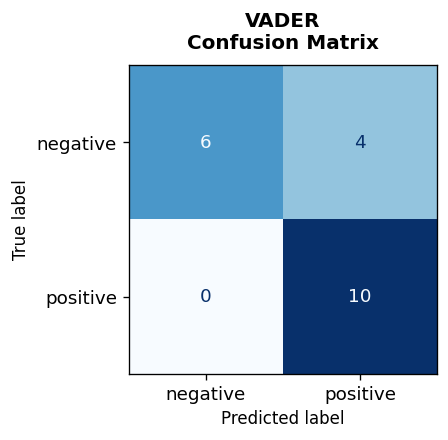

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

LABELS     = [0, 1]
LABEL_NAMES = ["negative", "positive"]

def print_metrics(name, y_true, y_pred):
    """Print accuracy, precision, recall, F1 and render a confusion matrix."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"{'='*52}")
    print(f"  {name} — Evaluation on held-out test set")
    print(f"{'='*52}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (macro avg)")
    print(f"  Recall    : {rec:.4f}  (macro avg)")
    print(f"  F1        : {f1:.4f}  (macro avg)")
    print()
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)
    plt.tight_layout()
    plt.show()

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}


vader = SentimentIntensityAnalyzer()

def vader_predict(texts, threshold=0.0):
    """Return 1 (positive) if compound >= threshold, else 0 (negative)."""
    preds = []
    for t in texts:
        score = vader.polarity_scores(t)["compound"]
        preds.append(1 if score >= threshold else 0)
    return np.array(preds)

vader_preds = vader_predict(X_test)
vader_metrics = print_metrics("VADER", y_test, vader_preds)

---
## Algorithm 2 · Bag-of-Words + Logistic Regression

  BoW + Logistic Regression — Evaluation on held-out test set
  Accuracy  : 0.7500
  Precision : 0.7747  (macro avg)
  Recall    : 0.7500  (macro avg)
  F1        : 0.7442  (macro avg)

              precision    recall  f1-score   support

    negative       0.86      0.60      0.71        10
    positive       0.69      0.90      0.78        10

    accuracy                           0.75        20
   macro avg       0.77      0.75      0.74        20
weighted avg       0.77      0.75      0.74        20



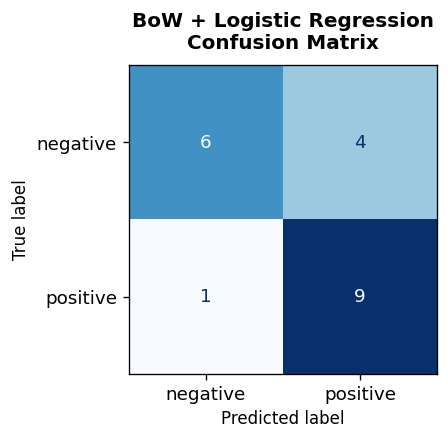

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

bow_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams
        min_df=1,
        max_features=5000,
        sublinear_tf=True     # apply log(tf) scaling
    )),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=42
    ))
])

bow_pipeline.fit(X_train, y_train)
bow_preds = bow_pipeline.predict(X_test)

bow_metrics = print_metrics("BoW + Logistic Regression", y_test, bow_preds)

In [6]:
# Top predictive tokens per class
import numpy as np

vectorizer = bow_pipeline.named_steps["tfidf"]
clf        = bow_pipeline.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())

top_n = 10
coefs = clf.coef_[0]
top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx = np.argsort(coefs)[:top_n]

print(f"Top {top_n} positive-stance tokens:", list(feature_names[top_pos_idx]))
print(f"Top {top_n} negative-stance tokens:", list(feature_names[top_neg_idx]))

Top 10 positive-stance tokens: ['this is', 'and', 'is', 'and the', 'well', 'thanks', 'good', 'for the', 'for', 'me']
Top 10 negative-stance tokens: ['doesn', 'that', 'too', 'not', 'will', 'don', 'cause', 'package', 'incorrect', 'this will']


---
## Algorithm 3 · BERT (distilbert-base-uncased, fine-tuned)
Fine-tunes a lightweight BERT variant on the training split.
Set `USE_GPU = True` if you have CUDA available.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

USE_GPU   = torch.cuda.is_available()
DEVICE    = torch.device("cuda" if USE_GPU else "cpu")
MODEL_ID  = "distilbert-base-uncased"
MAX_LEN   = 128
BATCH     = 8
EPOCHS    = 4
LR        = 2e-5

print(f"Device: {DEVICE}")

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(MODEL_ID)

/Users/Michael/repos/consensus/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [8]:
class CommentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_dataset = CommentDataset(X_train, y_train, tokenizer_bert, MAX_LEN)
test_dataset  = CommentDataset(X_test,  y_test,  tokenizer_bert, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 10  |  Test batches: 3


In [9]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=2
).to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ── Training loop ────────────────────────────────────────────────────────────
for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{EPOCHS}  |  avg loss: {avg_loss:.4f}")

print("Training complete.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8807.49it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4  |  avg loss: 0.6929
Epoch 2/4  |  avg loss: 0.6181
Epoch 3/4  |  avg loss: 0.5183
Epoch 4/4  |  avg loss: 0.4491
Training complete.


  BERT (distilbert-base-uncased) — Evaluation on held-out test set
  Accuracy  : 0.8000
  Precision : 0.8571  (macro avg)
  Recall    : 0.8000  (macro avg)
  F1        : 0.7917  (macro avg)

              precision    recall  f1-score   support

    negative       1.00      0.60      0.75        10
    positive       0.71      1.00      0.83        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



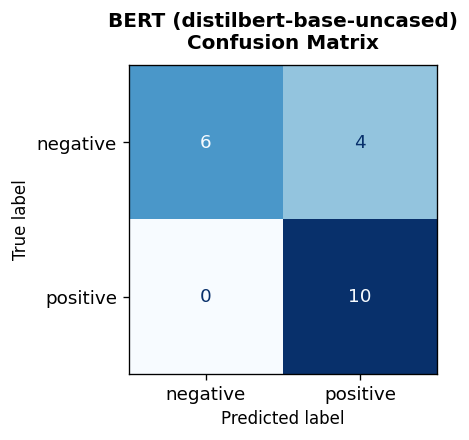

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        labels = batch.pop("labels").to(DEVICE)
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = bert_model(**batch).logits
        preds  = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_metrics = print_metrics("BERT (distilbert-base-uncased)", all_labels, all_preds)

---
## 3 · Side-by-side model comparison
Aggregates the accuracy, precision, recall, and F1 already printed per model above
into a single summary table and grouped bar chart.

=== Side-by-side comparison ===


,Accuracy,Precision,Recall,F1
Model,,,,
VADER,0.80,0.8571,0.80,0.7917
BoW + Logistic Regression,0.75,0.7747,0.75,0.7442
BERT (distilbert-base-uncased),0.80,0.8571,0.80,0.7917


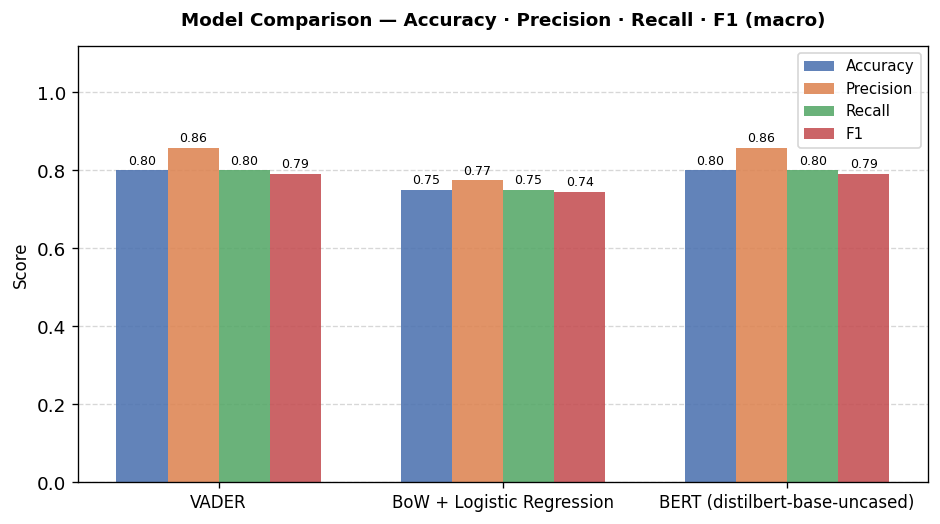

In [11]:
from sklearn.metrics import accuracy_score, f1_score

# Collect the metrics dicts returned by print_metrics() above
summary = pd.DataFrame([vader_metrics, bow_metrics, bert_metrics])
summary = summary.set_index("Model").round(4)

print("=== Side-by-side comparison ===")
display(summary)

# ── Bar chart of all four metrics ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
x       = np.arange(len(summary))
width   = 0.18
metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, summary[metric], width, label=metric, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.008,
            f"{h:.2f}", ha="center", va="bottom", fontsize=7.5
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary.index, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("Model Comparison — Accuracy · Precision · Recall · F1 (macro)",
             fontsize=11, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---
## 4 · Connect to MongoDB and fetch test data

In [12]:
from pymongo import MongoClient
import tiktoken
import json

with open("config.json") as f:
    config = json.load(f)

mongo_connection_string = config["mongo_uri"]
tokenizer = tiktoken.get_encoding("cl100k_base")

client     = MongoClient(mongo_connection_string)
db         = client.consensus
collection = db.python_pr_comments

# Fetch all documents
documents = list(collection.find({}))
print(f"Fetched {len(documents)} documents from MongoDB.")

Fetched 15 documents from MongoDB.


## 5 · Apply all three models to MongoDB documents

In [13]:
# Build a clean DataFrame from MongoDB docs
# Skips documents with empty or whitespace-only raw_text

live_records = []
for doc in documents:
    text = doc.get("raw_text", "").strip()
    if not text:
        continue
    live_records.append({
        "_id":    str(doc["_id"]),
        "author": doc.get("author", ""),
        "url":    doc.get("url", ""),
        "text":   text,
    })

live_df = pd.DataFrame(live_records)
print(f"Documents with non-empty text: {len(live_df)}")
live_df.head()

Documents with non-empty text: 15


,_id,author,url,text
0,69b0bbd1ffc385106ba5baef,hugovk,https://github.com/python/peps/pull/4831#discu...,```suggestion\ncryptography will be using roug...
1,69b0bbd2ffc385106ba5baf0,hugovk,https://github.com/python/peps/pull/4831#discu...,```suggestion\non Discourse for a free-threade...
2,69b0bbd2ffc385106ba5baf1,hugovk,https://github.com/python/peps/pull/4831#discu...,```suggestion\nBindings generators\n----------...
3,69b0bbd2ffc385106ba5baf2,hugovk,https://github.com/python/peps/pull/4831#discu...,I think it's fine to lightly edited quoted tex...
4,69b0bbd2ffc385106ba5baf3,encukou,https://github.com/python/peps/pull/4831#discu...,```suggestion\r\nconsiders switching to stable...


In [14]:
# ── VADER predictions ────────────────────────────────────────────────────────
live_df["vader_label"] = [
    "positive" if s >= 0.0 else "negative"
    for s in live_df["text"].map(
        lambda t: vader.polarity_scores(t)["compound"]
    )
]
live_df["vader_compound"] = live_df["text"].map(
    lambda t: round(vader.polarity_scores(t)["compound"], 4)
)

# ── BoW + LR predictions ─────────────────────────────────────────────────────
bow_live_preds = bow_pipeline.predict(live_df["text"])
bow_live_proba = bow_pipeline.predict_proba(live_df["text"])[:, 1]  # P(positive)
live_df["bow_label"]    = ["positive" if p == 1 else "negative" for p in bow_live_preds]
live_df["bow_prob_pos"] = bow_live_proba.round(4)

# ── BERT predictions ─────────────────────────────────────────────────────────
bert_model.eval()

def bert_predict_batch(texts, batch_size=16):
    labels, probs = [], []
    for i in range(0, len(texts), batch_size):
        chunk = list(texts[i: i + batch_size])
        enc   = tokenizer_bert(
            chunk,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            logits = bert_model(**enc).logits
        p     = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()
        labels.extend(["positive" if pr == 1 else "negative" for pr in preds])
        probs.extend(p[:, 1].tolist())   # P(positive)
    return labels, probs

bert_labels, bert_probs = bert_predict_batch(live_df["text"])
live_df["bert_label"]    = bert_labels
live_df["bert_prob_pos"] = [round(p, 4) for p in bert_probs]

print("Inference complete.")
live_df[["author", "text", "vader_label", "bow_label", "bert_label"]].head(10)

Inference complete.


,author,text,vader_label,bow_label,bert_label
0,hugovk,```suggestion\ncryptography will be using roug...,positive,negative,positive
1,hugovk,```suggestion\non Discourse for a free-threade...,positive,negative,positive
2,hugovk,```suggestion\nBindings generators\n----------...,positive,negative,positive
3,hugovk,I think it's fine to lightly edited quoted tex...,positive,negative,negative
4,encukou,```suggestion\r\nconsiders switching to stable...,positive,positive,positive
5,MLopez-Ibanez,Hi @ngoldbaum I am happy if you want to quote ...,positive,negative,positive
6,MLopez-Ibanez,"This sentence: ""It has a much smaller userbase...",positive,negative,negative
7,ngoldbaum,"> Also, one should maybe put ""smaller userbase...",positive,negative,negative
8,ogrisel,Another extra benefit: once major upstream pro...,positive,positive,positive
9,ngoldbaum,I think @davidhewitt is going to give me some ...,positive,negative,positive


## 6 · Agreement analysis across models

In [15]:
# Majority vote (2-of-3 agreement)
def majority_vote(row):
    votes = [row["vader_label"], row["bow_label"], row["bert_label"]]
    return "positive" if votes.count("positive") >= 2 else "negative"

live_df["majority_label"] = live_df.apply(majority_vote, axis=1)

# Agreement flag
live_df["all_agree"] = (
    (live_df["vader_label"] == live_df["bow_label"]) &
    (live_df["bow_label"]   == live_df["bert_label"])
)

print("Majority label distribution:")
print(live_df["majority_label"].value_counts())
print(f"\nAll-three-agree: {live_df['all_agree'].sum()} / {len(live_df)} documents")

print("\nPer-model positive rate:")
for col in ["vader_label", "bow_label", "bert_label"]:
    rate = (live_df[col] == "positive").mean()
    print(f"  {col:15s}: {rate:.1%}")

Majority label distribution:
majority_label
positive    12
negative     3
Name: count, dtype: int64

All-three-agree: 6 / 15 documents

Per-model positive rate:
  vader_label    : 100.0%
  bow_label      : 40.0%
  bert_label     : 80.0%


In [16]:
# Disagreement cases — useful for manual review / active learning
disagreements = live_df[~live_df["all_agree"]][["author", "text", "vader_label", "bow_label", "bert_label"]]
print(f"Disagreement cases: {len(disagreements)}")
disagreements.head(10)

Disagreement cases: 9


,author,text,vader_label,bow_label,bert_label
0,hugovk,```suggestion\ncryptography will be using roug...,positive,negative,positive
1,hugovk,```suggestion\non Discourse for a free-threade...,positive,negative,positive
2,hugovk,```suggestion\nBindings generators\n----------...,positive,negative,positive
3,hugovk,I think it's fine to lightly edited quoted tex...,positive,negative,negative
5,MLopez-Ibanez,Hi @ngoldbaum I am happy if you want to quote ...,positive,negative,positive
6,MLopez-Ibanez,"This sentence: ""It has a much smaller userbase...",positive,negative,negative
7,ngoldbaum,"> Also, one should maybe put ""smaller userbase...",positive,negative,negative
9,ngoldbaum,I think @davidhewitt is going to give me some ...,positive,negative,positive
13,davidhewitt,I can offer perspectives from both PyO3 as a b...,positive,negative,positive


## 7 · Write predictions back to MongoDB

In [17]:
from pymongo import UpdateOne
from bson import ObjectId

ops = []
for _, row in live_df.iterrows():
    ops.append(UpdateOne(
        {"_id": ObjectId(row["_id"])},
        {"$set": {
            "stance_predictions": {
                "vader":    {"label": row["vader_label"],  "compound": row["vader_compound"]},
                "bow_lr":   {"label": row["bow_label"],    "prob_pos": row["bow_prob_pos"]},
                "bert":     {"label": row["bert_label"],   "prob_pos": row["bert_prob_pos"]},
                "majority": row["majority_label"],
                "all_agree": bool(row["all_agree"]),
            }
        }}
    ))

if ops:
    result = collection.bulk_write(ops)
    print(f"Updated {result.modified_count} documents in MongoDB.")
else:
    print("No documents to update.")

Updated 15 documents in MongoDB.


## 8 · (Optional) Save predictions to CSV

In [18]:
output_cols = [
    "_id", "author", "url", "text",
    "vader_label", "vader_compound",
    "bow_label",   "bow_prob_pos",
    "bert_label",  "bert_prob_pos",
    "majority_label", "all_agree"
]

live_df[output_cols].to_csv("stance_predictions.csv", index=False)
print("Saved to stance_predictions.csv")

Saved to stance_predictions.csv


---
## 9 · (Optional) Save trained models to disk

In [19]:
import pickle, os

os.makedirs("models", exist_ok=True)

# BoW pipeline (includes TF-IDF vectorizer)
with open("models/bow_lr_pipeline.pkl", "wb") as f:
    pickle.dump(bow_pipeline, f)

# BERT model + tokenizer
bert_model.save_pretrained("models/bert_stance")
tokenizer_bert.save_pretrained("models/bert_stance")

# VADER needs no saved state — it uses a built-in lexicon

print("Models saved to ./models/")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.09it/s]

Models saved to ./models/
